# Setting up

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!unzip /content/drive/MyDrive/firefight_dataset.zip -d /content/

Archive:  /content/drive/MyDrive/firefight_dataset.zip
 extracting: /content/README.dataset.txt  
 extracting: /content/README.roboflow.txt  
   creating: /content/test/
 extracting: /content/test/1-2-3a_PNG.rf.13c8eef8474212d98f9d71fbe483e567.jpg  
 extracting: /content/test/11-1-1a_PNG.rf.7d21a95dec2082e15b7dc50aa734f2ca.jpg  
 extracting: /content/test/11-1-1b_PNG.rf.aa4392ddc59688f83e0e4ccd69a6c5b6.jpg  
 extracting: /content/test/11-2-2b_PNG.rf.82fea129e5d98526d35f11571dc6a5ea.jpg  
 extracting: /content/test/11-3-1b_PNG.rf.32d86ea109f2a0272401b319d90e8474.jpg  
 extracting: /content/test/12-1-1a_PNG.rf.fc0ed905d8958ce3bef32f2691a35a19.jpg  
 extracting: /content/test/2-1-3b_PNG.rf.b5a3a3c8d97fe314eac5b05041738d33.jpg  
 extracting: /content/test/3-1-3b_PNG.rf.377ac08bdf388323e18f7b9fbec8ec5b.jpg  
 extracting: /content/test/3-2-2a_PNG.rf.441833ca66d864dc3919c9b9de8c9568.jpg  
 extracting: /content/test/5-1-1b_PNG.rf.752accc69d2c53e4ff992128571a9ab2.jpg  
 extracting: /content/tes

**Implementing the customizzed dataset:**

In [32]:
import os
import json
from PIL import Image
from torch.utils.data import Dataset

class FireFightingDataset(Dataset):
    def __init__(self, coco_path, image_folder, transform=None):
        self.image_folder = image_folder
        self.transform = transform

        with open(coco_path) as f:
            coco = json.load(f)

        self.image_id_to_file = {img["id"]: img["file_name"] for img in coco["images"]}
        self.category_id_to_label = {cat["id"]: i for i, cat in enumerate(coco["categories"])}
        self.annotations = coco["annotations"]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        ann = self.annotations[idx]
        image_id = ann["image_id"]
        category_id = ann["category_id"]
        bbox = ann["bbox"]

        filename = self.image_id_to_file[image_id]
        img_path = os.path.join(self.image_folder, filename)
        img = Image.open(img_path).convert("RGB")

        x, y, w, h = bbox
        base_crop = img.crop((int(x), int(y), int(x + w), int(y + h)))

        # apply the transform twice like what mentioned in the paper
        if self.transform:
            view1 = self.transform(base_crop)
            view2 = self.transform(base_crop)
        else:
            view1 = base_crop
            view2 = base_crop

        label = self.category_id_to_label[category_id]

        return (view1, view2), label

**Implementing the pytorch version SimCLR Model:**

In [33]:
import torch.nn as nn
import torchvision.models as models

class SimCLRModel(nn.Module):
    def __init__(self, out_dim=128):
        super(SimCLRModel, self).__init__()
        # base encoder (was thinking to use resnet50, but making training too slow)
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.f = nn.Sequential(*list(resnet.children())[:-1])

        # projection head
        self.g = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim)
        )

    def forward(self, x):
        h = self.f(x).squeeze()
        z = self.g(h)

        return h, z

**Implementing the NT-Xent Loss:**

In [34]:
import torch
import torch.nn.functional as F

def nt_xent_loss(z1, z2, temperature=0.5):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    batch_size = z1.size(0)

    z = torch.cat((z1, z2), dim=0)
    sim_matrix = torch.exp(torch.mm(z, z.t().contiguous()) / temperature)

    mask = (torch.ones_like(sim_matrix) - torch.eye(2 * batch_size, device=sim_matrix.device)).bool()
    sim_matrix = sim_matrix.masked_select(mask).view(2 * batch_size, -1)

    pos_sim = torch.exp(torch.sum(z1 * z2, dim=-1) / temperature)
    pos_sim = torch.cat((pos_sim, pos_sim), dim=0)

    loss = (-torch.log(pos_sim / sim_matrix.sum(dim=-1))).mean()

    return loss

# Loading data & Training & Evaluation

In [35]:
import torchvision.transforms as T

distortion_strength = 1.

train_transform = T.Compose([
    T.RandomResizedCrop(size=224, scale=(0.08, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([
        T.ColorJitter(0.8*distortion_strength, 0.8*distortion_strength, 0.8*distortion_strength, 0.2*distortion_strength)     # Color jittering [4, 5]
    ], p=0.8),
    T.RandomGrayscale(p=0.2),
    T.RandomApply([
        T.GaussianBlur(kernel_size=int(0.1 * 224) | 1, sigma=(0.1, 2.0))
    ], p=0.5),
    T.ToTensor()
])

eval_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor()
])

**Initialize the dataset:**

In [36]:
train_dataset = FireFightingDataset(
    coco_path="/content/train/_annotations.coco.json",
    image_folder="/content/train",
    transform=train_transform
)

valid_dataset = FireFightingDataset(
    coco_path="/content/valid/_annotations.coco.json",
    image_folder="/content/valid",
    transform=eval_transform
)

In [37]:
print(f"Total training symbols: {len(train_dataset)}")
print(f"Total validation symbols: {len(valid_dataset)}")

Total training symbols: 2606
Total validation symbols: 755


**Loading Data:**

In [38]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

**Traning:**

In [40]:
from tqdm import tqdm

model = SimCLRModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)
losses = []
epochs = 5

print("Starting training...")
for epoch in range(epochs):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=True)
    for (view1, view2), _ in loop:
        view1, view2 = view1.to(device), view2.to(device)

        _, z1 = model(view1)
        _, z2 = model(view2)

        loss = nt_xent_loss(z1, z2, temperature=0.5)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    losses.append(total_loss / len(train_loader))
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(train_loader):.4f}")


Starting training...


Epoch [1/5]: 100%|██████████| 10/10 [01:19<00:00,  7.91s/it, loss=5.31]


Epoch [1/5], Loss: 5.6237


Epoch [2/5]: 100%|██████████| 10/10 [01:21<00:00,  8.14s/it, loss=5.21]


Epoch [2/5], Loss: 5.2138


...

Epoch [3/5], Loss: 5.0675


Epoch [4/5]: 100%|██████████| 10/10 [01:19<00:00,  7.90s/it, loss=4.97]


Epoch [4/5], Loss: 5.0000


Epoch [5/5]: 100%|██████████| 10/10 [01:17<00:00,  7.79s/it, loss=4.95]

Epoch [5/5], Loss: 4.9497


**Plotting Loss-Epoch Plot:**

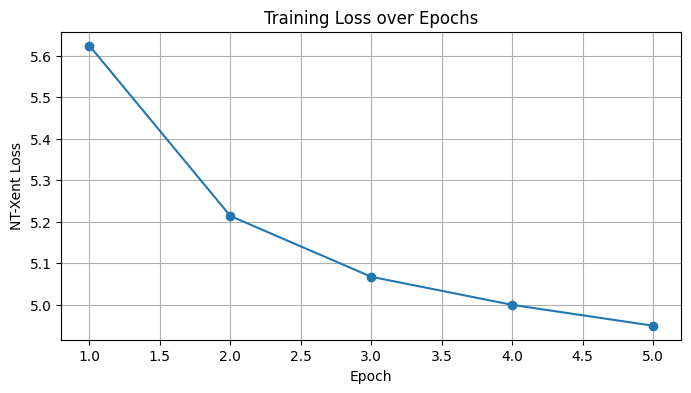

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(range(1, 6), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('NT-Xent Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

**Plotting t-SNE Plot:**

Evaling:
Running t-SNE...


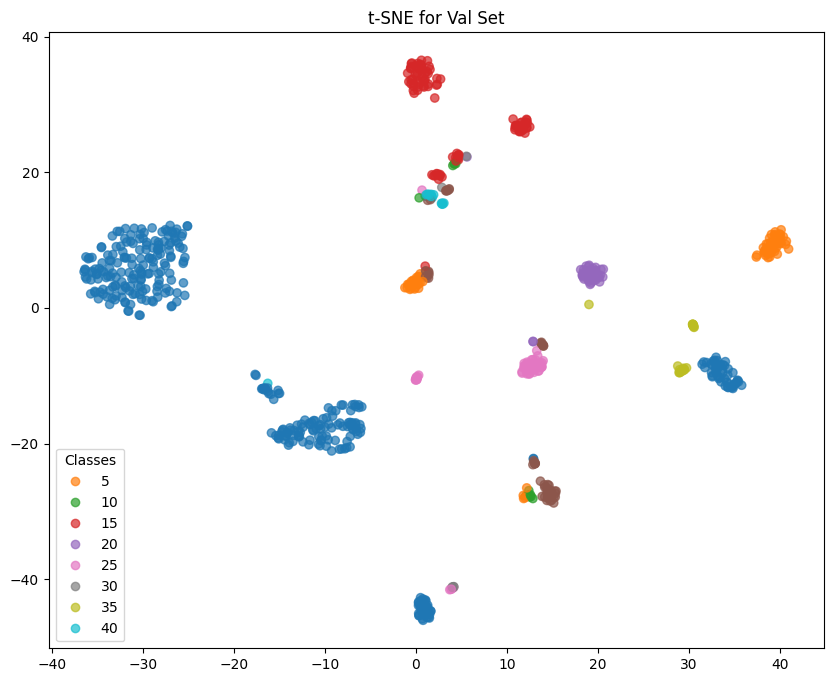

In [42]:
import numpy as np
from sklearn.manifold import TSNE

print("Evaling:")
model.eval()
representations = []
labels_list = []

with torch.no_grad():
    for (view1, view2), labels in valid_loader:
        view1 = view1.to(device)

        h, _ = model(view1)

        representations.append(h.cpu().numpy())
        labels_list.extend(labels.numpy())

h_reps = np.vstack(representations)
val_labels = np.array(labels_list)

print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42)
h_tsne = tsne.fit_transform(h_reps)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(h_tsne[:, 0], h_tsne[:, 1], c=val_labels, cmap='tab10', alpha=0.7)
handles, labels = scatter.legend_elements()
plt.legend(handles=handles, labels=labels, title="Classes")
plt.title("t-SNE for Val Set")
plt.show()

** **Trying with color distortion strength is 0**

In [43]:
distortion_strength = 0.

train_transform_ds = T.Compose([
    T.RandomResizedCrop(size=224, scale=(0.08, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([
        T.ColorJitter(0.8*distortion_strength, 0.8*distortion_strength, 0.8*distortion_strength, 0.2*distortion_strength)     # Color jittering [4, 5]
    ], p=0.8),
    T.RandomGrayscale(p=0.2),
    T.RandomApply([
        T.GaussianBlur(kernel_size=int(0.1 * 224) | 1, sigma=(0.1, 2.0))
    ], p=0.5),
    T.ToTensor()
])

eval_transform_ds = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor()
])

train_dataset_ds = FireFightingDataset(
    coco_path="/content/train/_annotations.coco.json",
    image_folder="/content/train",
    transform=train_transform_ds
)

valid_dataset_ds = FireFightingDataset(
    coco_path="/content/valid/_annotations.coco.json",
    image_folder="/content/valid",
    transform=eval_transform_ds
)

train_loader_ds = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=True)
valid_loader_ds = DataLoader(valid_dataset, batch_size=64, shuffle=False)

In [44]:
model_1 = SimCLRModel().to(device)
optimizer_1 = torch.optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)
losses = []
epochs = 5

print("Starting training...")
for epoch in range(epochs):
    model_1.train()
    total_loss = 0

    loop = tqdm(train_loader_ds, desc=f"Epoch [{epoch+1}/{epochs}]", leave=True)
    for (view1, view2), _ in loop:
        view1, view2 = view1.to(device), view2.to(device)

        _, z1 = model(view1)
        _, z2 = model(view2)

        loss = nt_xent_loss(z1, z2, temperature=0.5)

        optimizer_1.zero_grad()
        loss.backward()
        optimizer_1.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    losses.append(total_loss / len(train_loader))
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(train_loader):.4f}")


Starting training...


Epoch [1/5]: 100%|██████████| 10/10 [01:17<00:00,  7.75s/it, loss=5.39]


Epoch [1/5], Loss: 5.5897


Epoch [2/5]: 100%|██████████| 10/10 [01:18<00:00,  7.82s/it, loss=5.25]


Epoch [2/5], Loss: 5.2146


...

Epoch [3/5], Loss: 5.0796


Epoch [4/5]: 100%|██████████| 10/10 [01:20<00:00,  8.04s/it, loss=4.95]


Epoch [4/5], Loss: 4.9907


Epoch [5/5]: 100%|██████████| 10/10 [01:18<00:00,  7.84s/it, loss=4.98]

Epoch [5/5], Loss: 4.9514


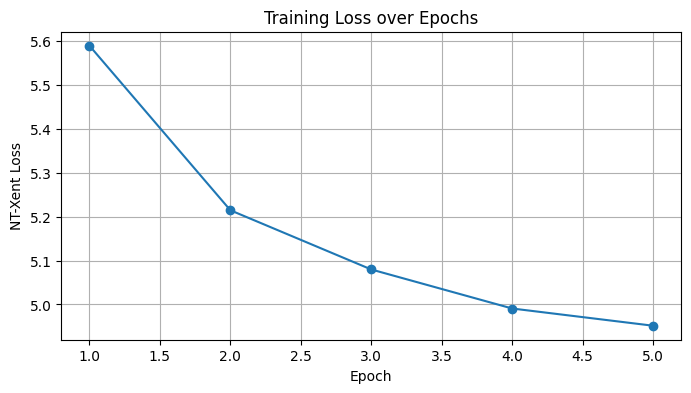

In [45]:
plt.figure(figsize=(8,4))
plt.plot(range(1, 6), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('NT-Xent Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

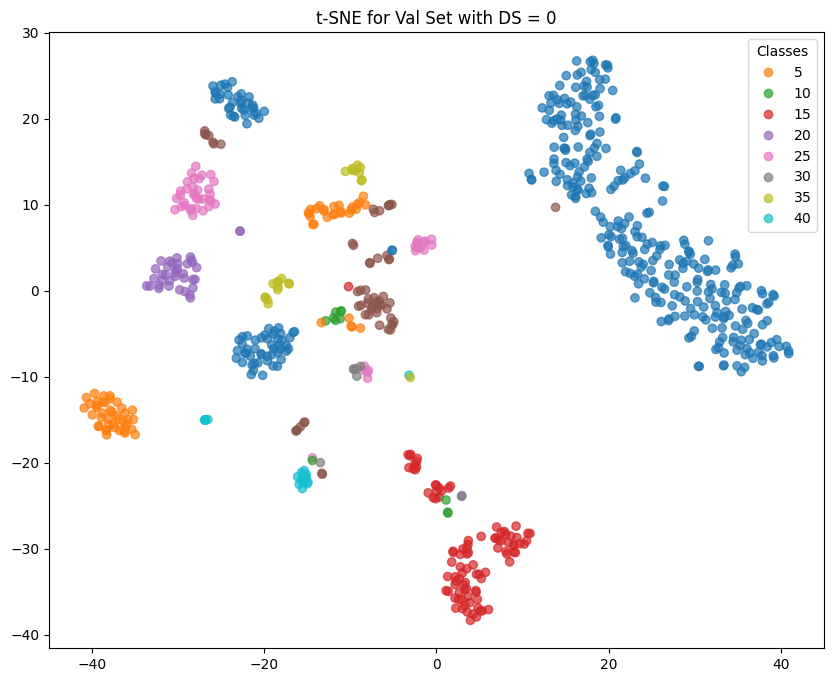

In [46]:
model_1.eval()
representations = []
labels_list = []

with torch.no_grad():
    for (view1, view2), labels in valid_loader_ds:
        view1 = view1.to(device)

        h, _ = model_1(view1)

        representations.append(h.cpu().numpy())
        labels_list.extend(labels.numpy())

h_reps = np.vstack(representations)
val_labels = np.array(labels_list)

tsne = TSNE(n_components=2, random_state=42)
h_tsne = tsne.fit_transform(h_reps)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(h_tsne[:, 0], h_tsne[:, 1], c=val_labels, cmap='tab10', alpha=0.7)
handles, labels = scatter.legend_elements()
plt.legend(handles=handles, labels=labels, title="Classes")
plt.title("t-SNE for Val Set with DS = 0")
plt.show()

# Wrapping and Comments

I did not implement the 1-shot matching demo due to the insurffient time, and here is what I will do if I have more time: calculate cosine similarity and the do the search: take one query symbol embedding, find top-k nearest neighbors across all validation embeddings, and visualize the matches to directly demonstrate 0-shot generalization.

Also, If more time I have, I would like to test larger batch sizes and more training epochs, which would likely yield tighter clusters by showing the model much more negative examples. I would also experiment with lowering the loss temperature, for example to 0.1, which will help the model learn from harder negatives.

As to the aspects of the couple plots i have for now, we can see that the loss is gradually decreasing along the time and iterations going, which is the good sign, and also I found that applying strong color distortion, here I used 1, prevented the model from using simple color as a shortcut to match image crops, forcing it to learn the true underlying patterns of the symbols, which i think that the stronger color distortion will result in the tighter clustering results.

I also moved the training from local to Google Colab with L4 GPU, and chose ResNet18 over ResNet50 because ResNet50 caused out-of-memory errors on the available GPU with batch size 256.

At last, if more time are given, I will also consider to dockerize the pipeline to pin all the dependencies and make sure it can be run on any machine with a single command.